In [45]:
from simulator import Config, Simulator

config = Config()
config.NODE_POWER_W = 0.02  # Node power consumption in kW
simulator = Simulator(config)

# CSV including time series data for production (G(h) in kWh, and Temperature in °C)
production_data = "raw-data/CR.csv"

In [46]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

## Run Complete Simulation

This single function call executes the entire pipeline:
1. Load irradiance data
2. Compute PV power for all panel sizes
3. Compute hourly power balance with PMU efficiency
4. Simulate battery State of Charge for all configurations
5. Evaluate viability and compute scores

In [47]:
# Run the full simulation
results = simulator.run_full_simulation(production_data)

# Extract results
df_pv = results['df_pv']
df_pv_pmu = results['df_pv_pmu']
df_soc = results['df_soc']
summary = results['summary']

Loading irradiance data...
Computing PV power...
Computing hourly balance...
Simulating battery SoC...
Evaluating viability...
Computing optimal scores...
Done!


## Design space

In [48]:
df_design = simulator.build_design_space()
df_design

,panel_area_m2,battery_capacity_mAh,eta_PMU
0,0.0001,30,0.87
1,0.0001,30,0.90
2,0.0001,30,0.95
3,0.0001,30,0.98
4,0.0001,70,0.87
...,...,...,...
611,0.0400,4000,0.98
612,0.0400,5400,0.87
613,0.0400,5400,0.90
614,0.0400,5400,0.95


## Explore Results

In [49]:
print("Top 10 configurations by score:")
summary.head(10)

Top 10 configurations by score:


,panel_area_m2,C_batt_mAh,eta_PMU,hours_total,hours_soc_min,hours_soc_full,soc_mean,soc_std,surplus_mAh,deficit_mAh,autonomy_hours,failure_hours,I_batt_max_A,I_req_max_A,soc_min_fraction,soc_full_fraction,net_mAh,score
0,0.0040,135,0.98,8760,0,3313,0.821871,0.191458,257671.252117,24759.488516,8760,0,0.4,0.163072,0.0,0.378196,232911.763602,0.627568
1,0.0040,135,0.95,8760,0,3278,0.820609,0.191990,249118.275863,24785.995372,8760,0,0.4,0.157914,0.0,0.374201,224332.280491,0.627568
2,0.0040,270,0.87,8760,0,3208,0.908212,0.097123,226317.085650,24863.426788,8760,0,0.8,0.144161,0.0,0.366210,201453.658862,0.619188
3,0.0040,270,0.90,8760,0,3235,0.909112,0.096569,234866.519402,24833.377429,8760,0,0.8,0.149318,0.0,0.369292,210033.141973,0.619188
4,0.0040,270,0.95,8760,0,3278,0.910304,0.095995,249118.275863,24785.995372,8760,0,0.8,0.157914,0.0,0.374201,224332.280491,0.619188
5,0.0040,270,0.98,8760,0,3313,0.910936,0.095729,257671.252117,24759.488516,8760,0,0.8,0.163072,0.0,0.378196,232911.763602,0.619188
6,0.0025,500,0.98,8760,0,2827,0.943848,0.059465,153060.302205,25247.206710,8760,0,1.5,0.099893,0.0,0.322717,127813.095494,0.617442
7,0.0025,500,0.95,8760,0,2783,0.943077,0.060391,147737.802214,25286.883664,8760,0,1.5,0.096669,0.0,0.317694,122450.918550,0.617442
8,0.0025,500,0.90,8760,0,2715,0.941654,0.062171,138873.862669,25359.905693,8760,0,1.5,0.091297,0.0,0.309932,113513.956976,0.617442
9,0.0025,500,0.87,8760,0,2674,0.940664,0.063459,133560.477614,25408.697582,8760,0,1.5,0.088074,0.0,0.305251,108151.780032,0.617442


## Plot best configurations

Visualize all configurations in 3D space (panel area × battery capacity × PMU efficiency)

In [50]:
LOG_COLOR = False

data = summary.copy()

if LOG_COLOR:
    eps = 1e-9
    data["score_color"] = np.log10(data["score"] + eps)
    color_label = "log10(score)"
else:
    data["score_color"] = data["score"]
    color_label = "score"

fig = px.scatter_3d(
    data,
    x="panel_area_m2",
    y="C_batt_mAh",
    z="eta_PMU",
    color="score_color",
    labels={
        "panel_area_m2": "Panel area (m²)",
        "C_batt_mAh": "Battery (mAh)",
        "eta_PMU": "PMU efficiency",
        "score_color": color_label
    },
    opacity=0.85
)

fig.update_layout(
    width=1000,
    height=800,
    title=f"All configurations ({'log color scale' if LOG_COLOR else 'linear color scale'})"
)

fig.show()

## Score Distribution Histogram

In [51]:
fig = px.histogram(
    summary,
    x="score",
    nbins=50,
    labels={"score": "score"},
    opacity=0.85,
)

fig.update_layout(
    width=900,
    height=500,
    title="Score distribution",
    bargap=0.05
)

fig.show()

## 3D Surface Plot: Score at Maximum PMU Efficiency (not best configs)

In [52]:
eta_max = summary["eta_PMU"].max()
df_plane = summary[summary["eta_PMU"] == eta_max].copy()

df_pivot = (
    df_plane
    .pivot_table(
        index="C_batt_mAh",
        columns="panel_area_m2",
        values="score",
        aggfunc="mean"
    )
    .sort_index()
    .sort_index(axis=1)
)

X = df_pivot.columns.values
Y = df_pivot.index.values
X_grid, Y_grid = np.meshgrid(X, Y)
Z = df_pivot.values

fig = go.Figure(
    data=[
        go.Surface(
            x=X_grid,
            y=Y_grid,
            z=Z,
            colorscale="Viridis",
            colorbar={"title": "Score"}
        )
    ]
)

fig.update_layout(
    title=f"Score surface for max η_PMU ({eta_max})",
    scene=dict(
        xaxis_title="Panel area (m²)",
        yaxis_title="Battery capacity (mAh)",
        zaxis_title="Score"
    ),
    width=900,
    height=700
)

fig.show()

## Custom Analysis

You can also access individual simulation steps for custom analysis:

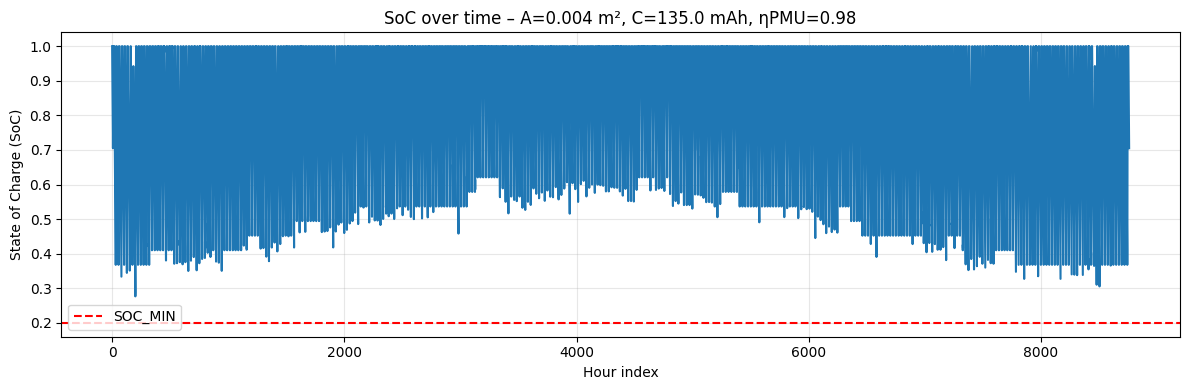

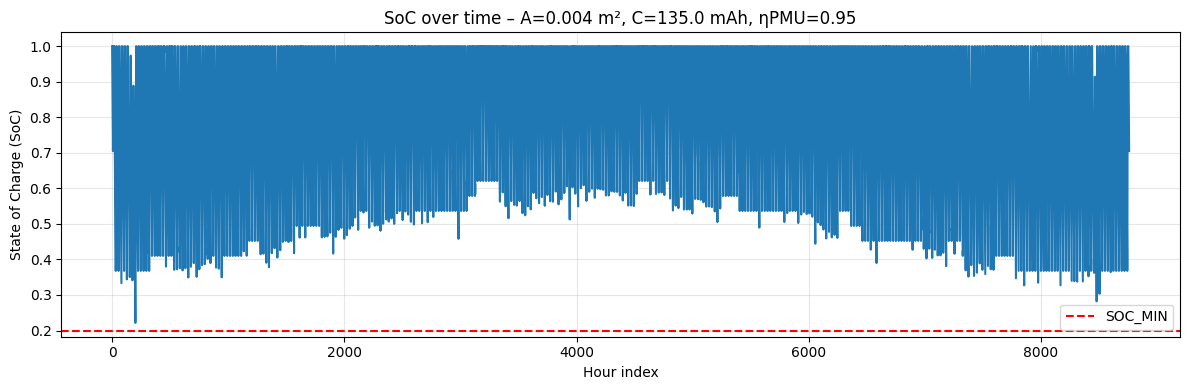

In [53]:
# Example: Analyze a specific configuration's SoC over time
for _, cfg in best_configs.iterrows():
    config_soc = df_soc[
        (df_soc['panel_area_m2'] == cfg['panel_area_m2']) &
        (df_soc['C_batt_mAh'] == cfg['C_batt_mAh']) &
        (df_soc['eta_PMU'] == cfg['eta_PMU'])
    ].copy()

    plt.figure(figsize=(12, 4))
    plt.plot(config_soc['hour_index'], config_soc['SoC'])
    plt.axhline(y=Config.SOC_MIN, color='r', linestyle='--', label='SOC_MIN')
    plt.xlabel('Hour index')
    plt.ylabel('State of Charge (SoC)')
    plt.title(
        f"SoC over time – A={cfg['panel_area_m2']} m², "
        f"C={cfg['C_batt_mAh']} mAh, ηPMU={cfg['eta_PMU']}"
    )
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## Summary statistics

In [54]:

print("\n=== Simulation Summary ===")
print(f"Total configurations evaluated: {len(summary)}")
print(f"Configurations with zero failures: {len(summary[summary['failure_hours'] == 0])}")
print(f"Best score achieved: {summary['score'].max():.4f}")
print(f"Configurations with best score: {len(summary[summary['score'] == summary['score'].max()])}")


=== Simulation Summary ===
Total configurations evaluated: 616
Configurations with zero failures: 322
Best score achieved: 0.6276
Configurations with best score: 2


## Invalidad configs due to < SoC_min

In [55]:
invalid_soc = summary[summary["failure_hours"] > 0][[
    "panel_area_m2",
    "C_batt_mAh",
    "eta_PMU",
    "failure_hours",
    "autonomy_hours",
    "I_batt_max_A",
    "I_req_max_A"
]].sort_values("failure_hours", ascending=False)

invalid_soc


,panel_area_m2,C_batt_mAh,eta_PMU,failure_hours,autonomy_hours,I_batt_max_A,I_req_max_A
565,0.0001,30,0.98,8755,5,0.1,0.005405
387,0.0001,30,0.87,8755,5,0.1,0.005405
397,0.0001,30,0.90,8755,5,0.1,0.005405
388,0.0001,30,0.95,8755,5,0.1,0.005405
574,0.0001,70,0.95,8749,11,0.2,0.005405
...,...,...,...,...,...,...,...
559,0.0025,270,0.90,5,8535,0.8,0.091297
507,0.0040,135,0.87,4,8559,0.4,0.144161
506,0.0040,135,0.90,3,8559,0.4,0.149318
558,0.0025,270,0.95,3,8535,0.8,0.096669


## Invalid configs due I_req > I_batt_max

In [56]:
invalid_peak = summary[
    summary["I_req_max_A"] > summary["I_batt_max_A"]
][[
    "panel_area_m2",
    "C_batt_mAh",
    "eta_PMU",
    "I_req_max_A",
    "I_batt_max_A",
    "failure_hours",
    "autonomy_hours"
]].sort_values("I_req_max_A", ascending=False)

invalid_peak


,panel_area_m2,C_batt_mAh,eta_PMU,I_req_max_A,I_batt_max_A,failure_hours,autonomy_hours
226,0.04000,135,0.98,1.679365,0.4,0,8760
561,0.04000,30,0.98,1.679365,0.1,2930,19
404,0.04000,70,0.98,1.679365,0.2,1082,1199
242,0.04000,500,0.98,1.679365,1.5,0,8760
237,0.04000,270,0.98,1.679365,0.8,0,8760
...,...,...,...,...,...,...,...
460,0.00625,70,0.87,0.228292,0.2,1191,214
496,0.00400,30,0.98,0.163072,0.1,3163,19
497,0.00400,30,0.95,0.157914,0.1,3168,19
498,0.00400,30,0.90,0.149318,0.1,3177,19
